<a href="https://colab.research.google.com/github/KhuslenP/PythonProject1/blob/feature/CelebrityFaces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import files
files.upload()  # Nahraj soubor kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khuslenpurevsuren","key":"27820062fa3b7fea629dad9292f216c5"}'}

In [12]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [13]:
!kaggle datasets download -d vishesh1412/celebrity-face-image-dataset


Dataset URL: https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset
License(s): CC0-1.0
  0% 0.00/52.9M [00:00<?, ?B/s]
100% 52.9M/52.9M [00:00<00:00, 1.11GB/s]


In [14]:
import zipfile
import os

# Rozbalení zip souboru
with zipfile.ZipFile("celebrity-face-image-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("celebrity_faces")

# Seznam složek
print(os.listdir("celebrity_faces"))

['Celebrity Faces Dataset']


In [1]:
!pip install mtcnn tensorflow==2.12.0

In [2]:
!pip install mtcnn

In [4]:

# 📦 Načteme potřebné knihovny
import os
import numpy as np
from PIL import Image
from mtcnn import MTCNN
import cv2
import math

# 📐 Nastavení velikosti výstupního obrázku
img_height, img_width = 100, 100
max_images_per_class = 90

# 📁 Cesty k datům
vstupni_slozka = 'celebrity_faces/Celebrity Faces Dataset'
vystupni_slozka = 'ProcessedFaces'
os.makedirs(vystupni_slozka, exist_ok=True)

# 👀 Detektor obličejů
detektor = MTCNN()

# 🎯 Zarovnání obličeje podle očí

def zarovnej_oblicej(img_pil):
    img_pil = img_pil.convert('RGB')
    img_np = np.array(img_pil)
    vysledek = detektor.detect_faces(img_np)
    if not vysledek:
        return None

    oci = vysledek[0]['keypoints']
    leva_oko = oci['left_eye']
    prava_oko = oci['right_eye']

    dx = prava_oko[0] - leva_oko[0]
    dy = prava_oko[1] - leva_oko[1]
    uhel = math.degrees(math.atan2(dy, dx))

    stred = np.mean([leva_oko, prava_oko], axis=0).astype(np.float32)
    rotace = cv2.getRotationMatrix2D(tuple(stred), uhel, 1.0)
    zarovnany = cv2.warpAffine(img_np, rotace, (img_np.shape[1], img_np.shape[0]))
    zarovnany_rgb = cv2.cvtColor(zarovnany, cv2.COLOR_BGR2RGB)

    return Image.fromarray(zarovnany_rgb)

# ✂️ Ořez obličeje

def orez_oblicej(img_pil):
    img_np = np.array(img_pil)
    vysledek = detektor.detect_faces(img_np)
    if not vysledek:
        return None
    try:
        x, y, w, h = vysledek[0]['box']
        return img_pil.crop((x, y, x + w, y + h))
    except:
        return None

# 🧹 Projdi všechny složky celebrit
for jmeno in os.listdir(vstupni_slozka):
    slozka_celebrity = os.path.join(vstupni_slozka, jmeno)
    if os.path.isdir(slozka_celebrity):
        cilova_slozka = os.path.join(vystupni_slozka, jmeno)
        os.makedirs(cilova_slozka, exist_ok=True)

        for soubor in os.listdir(slozka_celebrity):
            if soubor.lower().endswith(('.jpg', '.jpeg', '.png')):
                cesta = os.path.join(slozka_celebrity, soubor)
                try:
                    img = Image.open(cesta).convert('RGB')
                    zarovnany = zarovnej_oblicej(img)
                    if zarovnany is None:
                        continue
                    orezany = orez_oblicej(zarovnany)
                    if orezany is None:
                        continue
                    upraveny = orezany.resize((img_width, img_height))
                    upraveny.save(os.path.join(cilova_slozka, soubor))
                except Exception as e:
                    print(f"❌ Chyba u {soubor}: {e}")

print("✅ Hotovo! Obrázky jsou zarovnány, oříznuty a uloženy ve složce 'ProcessedFaces'")

✅ Hotovo! Obrázky jsou zarovnány, oříznuty a uloženy ve složce 'ProcessedFaces'


In [6]:
from collections import defaultdict
import random

input_root = "ProcessedFaces"
max_images_per_class = 90

vyvazene_obrazky = []
vyvazene_stitky = []

for osoba in os.listdir(input_root):
    slozka = os.path.join(input_root, osoba)
    if os.path.isdir(slozka):
        obrazky = [os.path.join(slozka, f) for f in os.listdir(slozka) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(obrazky) > max_images_per_class:
            obrazky = random.sample(obrazky, max_images_per_class)
        vyvazene_obrazky.extend(obrazky)
        vyvazene_stitky.extend([osoba] * len(obrazky))

print(f"✅ Vyvážený dataset připraven: {len(vyvazene_obrazky)} obrázků, {len(set(vyvazene_stitky))} tříd.")


✅ Vyvážený dataset připraven: 1529 obrázků, 17 tříd.


In [20]:
vyvazene_stitky = [os.path.basename(os.path.dirname(path)) for path in vyvazene_obrazky]


Epoch 1/10
44/44 [==============================] - 26s 569ms/step - loss: 2.7836 - accuracy: 0.1271 - val_loss: 2.4790 - val_accuracy: 0.2051
Epoch 2/10
44/44 [==============================] - 30s 698ms/step - loss: 2.0286 - accuracy: 0.3869 - val_loss: 1.7198 - val_accuracy: 0.4644
Epoch 3/10
44/44 [==============================] - 25s 569ms/step - loss: 1.3136 - accuracy: 0.5996 - val_loss: 1.4662 - val_accuracy: 0.5983
Epoch 4/10
44/44 [==============================] - 24s 538ms/step - loss: 0.8307 - accuracy: 0.7566 - val_loss: 1.3794 - val_accuracy: 0.6268
Epoch 5/10
44/44 [==============================] - 24s 543ms/step - loss: 0.5348 - accuracy: 0.8394 - val_loss: 1.3075 - val_accuracy: 0.6467
Epoch 6/10
44/44 [==============================] - 25s 563ms/step - loss: 0.2623 - accuracy: 0.9372 - val_loss: 1.3157 - val_accuracy: 0.6895
Epoch 7/10
44/44 [==============================] - 23s 528ms/step - loss: 0.1424 - accuracy: 0.9657 - val_loss: 1.3690 - val_accuracy: 0.6895

<Figure size 1200x1000 with 0 Axes>

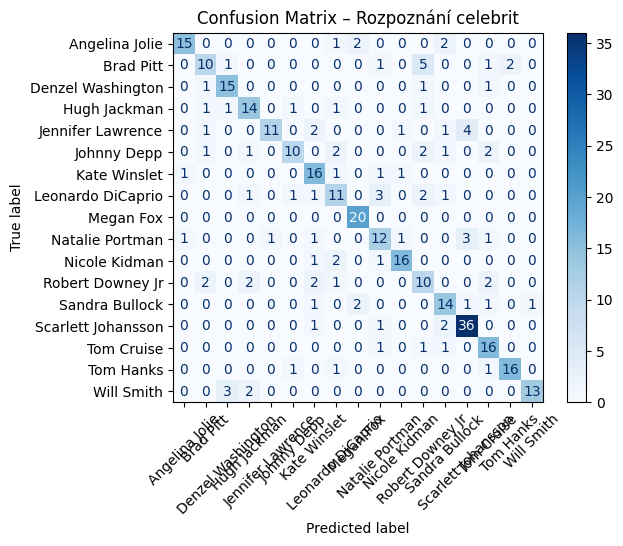


🔄 Nejvíce zaměňované celebrity: Brad Pitt ↔ Robert Downey Jr

📌 Top 3 nejčastější záměny:
Brad Pitt ↔ Robert Downey Jr : 5 případů
Jennifer Lawrence ↔ Scarlett Johansson : 4 případů
Leonardo DiCaprio ↔ Natalie Portman : 3 případů

📋 Přehled přesnosti a F1 skóre:
                    precision    recall  f1-score   support

    Angelina Jolie       0.88      0.75      0.81        20
         Brad Pitt       0.62      0.50      0.56        20
 Denzel Washington       0.75      0.83      0.79        18
      Hugh Jackman       0.70      0.74      0.72        19
 Jennifer Lawrence       0.92      0.55      0.69        20
       Johnny Depp       0.77      0.53      0.62        19
      Kate Winslet       0.64      0.80      0.71        20
 Leonardo DiCaprio       0.55      0.55      0.55        20
         Megan Fox       0.83      1.00      0.91        20
   Natalie Portman       0.60      0.60      0.60        20
     Nicole Kidman       0.84      0.80      0.82        20
  Robert Downey

In [27]:
import os
import glob
import numpy as np
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model

# 📁 Načti cesty k obrázkům
image_paths = glob.glob('ProcessedFaces/*/*.jpg')  # nebo *.png dle potřeby

# 🏷️ Načti obrázky a štítky podle složek
X = []
y = []

for path in image_paths:
    try:
        img = Image.open(path).convert('RGB').resize((100, 100))
        X.append(np.array(img) / 255.0)
        label = os.path.basename(os.path.dirname(path))  # složka = štítek
        y.append(label)
    except Exception as e:
        print(f"❌ Chyba při načítání {path}: {e}")

X = np.array(X)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

# 🔀 Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded)

# 🧠 CNN model
vstup = tf.keras.Input(shape=(100, 100, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(vstup)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
vystup = layers.Dense(len(np.unique(y_encoded)), activation='softmax')(x)
model = Model(inputs=vstup, outputs=vystup)

# ⚙️ Kompilace a trénink
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# 📊 Confusion Matrix
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix – Rozpoznání celebrit")
plt.grid(False)
plt.show()

# 🧠 Nejčastější záměny
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_wo_diag = cm.copy()
np.fill_diagonal(cm_wo_diag, 0)

most_confused = np.unravel_index(np.argmax(cm_wo_diag), cm_wo_diag.shape)
print(f"\n🔄 Nejvíce zaměňované celebrity: {class_names[most_confused[0]]} ↔ {class_names[most_confused[1]]}")

# 🔝 Top 3 nejčastější záměny
flat = [(i, j, cm_wo_diag[i, j]) for i in range(len(class_names)) for j in range(len(class_names)) if i != j]
flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:3]
print("\n📌 Top 3 nejčastější záměny:")
for i, j, count in flat_sorted:
    print(f"{class_names[i]} ↔ {class_names[j]} : {count} případů")

# 📋 Přesnost a F1 skóre
print("\n📋 Přehled přesnosti a F1 skóre:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))


In [16]:


## 🧠 Trénink modelu CNN

# 📦 Importy
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import glob
import os

# 📁 Cesty k obrázkům
vyvazene_obrazky = glob.glob('ProcessedFaces/*/*.jpg')  # uprav dle formátu např. .png

# 🏷️ Načtení obrázků a štítků
X = []
y = []

for path in vyvazene_obrazky:
    try:
        img = Image.open(path).convert('RGB').resize((100, 100))
        X.append(np.array(img) / 255.0)
        label = os.path.basename(os.path.dirname(path))  # složka jako štítek
        y.append(label)
    except Exception as e:
        print(f"Chyba u obrázku: {path} – {e}")

X = np.array(X)
y = LabelEncoder().fit_transform(y)

# 🔀 Rozdělení dat
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# 🏗️ Definice CNN modelu
vstup = tf.keras.Input(shape=(100, 100, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(vstup)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
vystup = layers.Dense(len(np.unique(y)), activation='softmax')(x)

model = Model(inputs=vstup, outputs=vystup)

# ⚙️ Kompilace modelu
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🚀 Trénink
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# 📉 Vyhodnocení
loss, acc = model.evaluate(X_test, y_test)
print(f"📊 Přesnost na testovacích datech: {acc:.2%}")

# 💾 Uložení modelu
model.save("celebrity_face_model.h5")



Epoch 1/10
44/44 [==============================] - 35s 779ms/step - loss: 2.7216 - accuracy: 0.1356 - val_loss: 2.3843 - val_accuracy: 0.2479
Epoch 2/10
44/44 [==============================] - 24s 548ms/step - loss: 1.8878 - accuracy: 0.4118 - val_loss: 1.7931 - val_accuracy: 0.4644
Epoch 3/10
44/44 [==============================] - 26s 602ms/step - loss: 1.2071 - accuracy: 0.6374 - val_loss: 1.4622 - val_accuracy: 0.5527
Epoch 4/10
44/44 [==============================] - 24s 545ms/step - loss: 0.7280 - accuracy: 0.7816 - val_loss: 1.2702 - val_accuracy: 0.6353
Epoch 5/10
44/44 [==============================] - 23s 533ms/step - loss: 0.3904 - accuracy: 0.8901 - val_loss: 1.3171 - val_accuracy: 0.6524
Epoch 6/10
44/44 [==============================] - 22s 501ms/step - loss: 0.1998 - accuracy: 0.9550 - val_loss: 1.2940 - val_accuracy: 0.6752
Epoch 7/10
44/44 [==============================] - 24s 544ms/step - loss: 0.1241 - accuracy: 0.9757 - val_loss: 1.3581 - val_accuracy: 0.6581

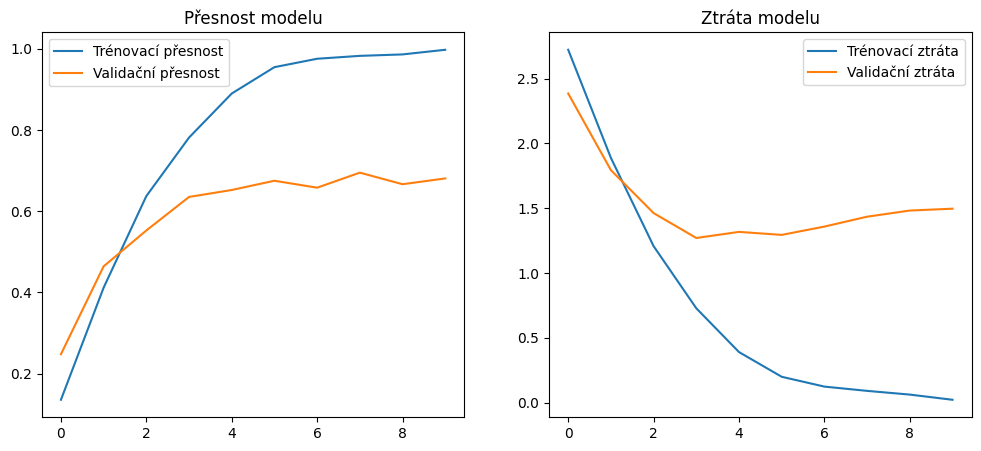

In [22]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Trénovací přesnost')
plt.plot(epochs_range, val_acc, label='Validační přesnost')
plt.legend()
plt.title('Přesnost modelu')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Trénovací ztráta')
plt.plot(epochs_range, val_loss, label='Validační ztráta')
plt.legend()
plt.title('Ztráta modelu')

plt.show()


11/11 [==============================] - 2s 173ms/step


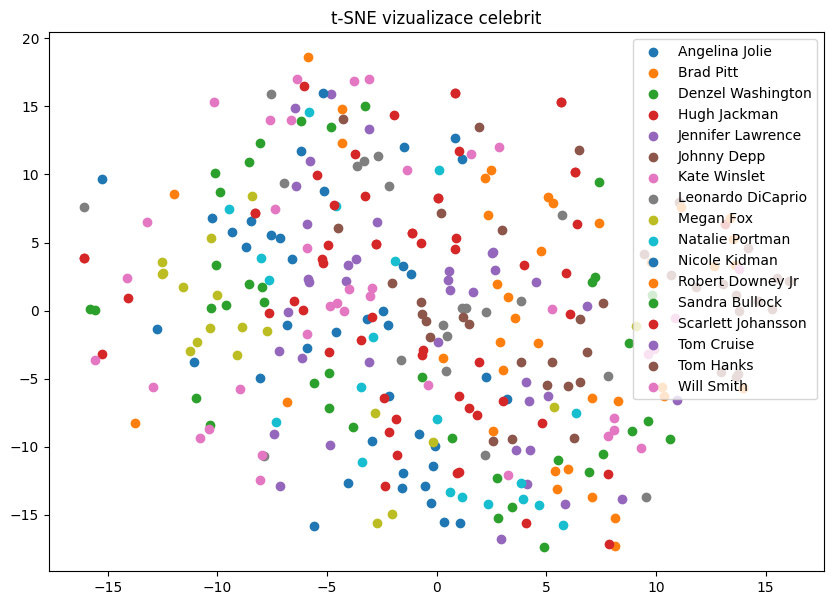

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 🧠 Vytvoření modelu pro extrakci příznaků z poslední vrstvy před výstupem
feature_extractor = tf.keras.Model(inputs=model.input, outputs=model.layers[-3].output)

# 🎯 Získání příznaků z testovacích dat
features = feature_extractor.predict(X_test)
labels_list = y_test  # už je zakódovaný

# 🎨 Redukce dimenze pomocí t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced_features = tsne.fit_transform(features)

# 🖼️ Vykreslení t-SNE
plt.figure(figsize=(10, 7))
for i, label in enumerate(np.unique(labels_list)):
    indices = np.where(np.array(labels_list) == label)
    plt.scatter(reduced_features[indices, 0], reduced_features[indices, 1], label=class_names[label])

plt.legend()
plt.title('t-SNE vizualizace celebrit')
plt.show()

